# Softmax Regression Project - Iris Dataset

The goal is this notebook is to use Scikit-Learn's and from scratch **softmax regression models** to implement a complete machine learning project using Scikit-Learn's Iris dataset.

## 1. Imports

In [19]:
# Imports
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

import joblib

from softmax_regression import SoftmaxRegression

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)
df['target'] = load_iris().target 

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df["target"].unique()

array([0, 1, 2])

In [8]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [6]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (150, 5)
Head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Description:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000 

**Feature scales (mean and standard deviation)**:
- sepal length: mean 5.84, standard deviation 0.83
- petal length: mean 3.76, standard deviation 1.77

The features are not on the same scale. 

Petal length ranges from 1.0 to 6.9, sepal width from 2.0 to 4.4. This is a clear sign that scaling will be necessary before gradient descent—otherwise, features with large values will dominate the gradients.

**Missing values**: zero everywhere, clean dataset. No preprocessing needed on this front.

Target distribution: mean = 1.0, min = 0, max = 2. 

The **3 classes are perfectly balanced** (50 examples each). No class imbalance issues.

**Min/max**: nothing abnormal, no obvious outliers.

## 3. Train and test datasets

In [9]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [10]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**What is the difference between fit_transform() and transform() functions?**

**fit** calculates the mean and standard deviation for each feature. 

**transform** applies normalization using these pre-calculated values.

**fit_transform** does both at once: it calculates AND applies the normalization to X_train.

**transform** alone only applies the normalization, using the pre-calculated values on X_train.

If we ran **fit_transform** on X_test, the scaler would calculate a new mean and standard deviation based on the test set slightly different values. 

The model was trained with the train scale, so in production it will receive data normalized to the train scale. Using the test scale during evaluation simulates a situation that does not exist in production, this is **data leakage**.

## 4. Train the model with Softmax Regression from scratch

In [16]:
# Train and fit the scratch Softmax Regression model
model_scratch = SoftmaxRegression(learning_rate=0.01, num_iterations=5000)
model_scratch.fit(X_train_scaled, y_train)

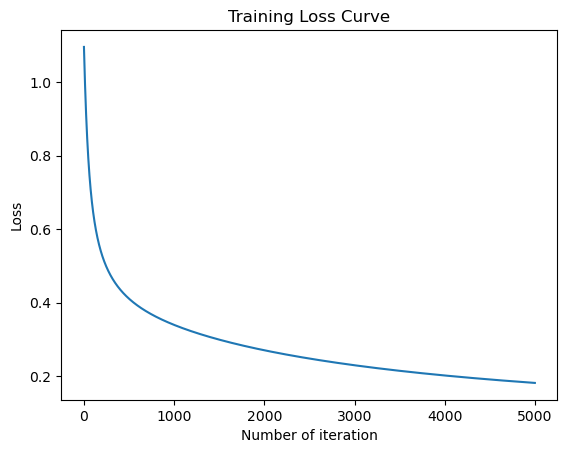

In [17]:
# Visualize the loss history
plt.plot(model_scratch.losses)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

The loss curve converges properly.

In [24]:
# Evaluate the scratch model
# Train set evaluation
predictions_scratch_train = model_scratch.predict(X_train_scaled)
accuracy_scratch_train = accuracy_score(y_train, predictions_scratch_train)
f1_score_scratch_train = f1_score(y_train, predictions_scratch_train, average='micro')
recall_scratch_train = recall_score(y_train, predictions_scratch_train, average='micro')

print("Scratch Softmax Regression - Train Accuracy:", accuracy_scratch_train)
print("Scratch Softmax Regression - Train F1 Score:", f1_score_scratch_train)
print("Scratch Softmax Regression - Train Recall:", recall_scratch_train)

Scratch Logistic Regression - Train Accuracy: 0.95
Scratch Logistic Regression - Train F1 Score: 0.95
Scratch Logistic Regression - Train Recall: 0.95


In [26]:
# Test set evaluation
predictions_scratch_test = model_scratch.predict(X_test_scaled)
accuracy_scratch_test = accuracy_score(y_test, predictions_scratch_test)
f1_score_scratch_test = f1_score(y_test, predictions_scratch_test, average='micro')
recall_scratch_test = recall_score(y_test, predictions_scratch_test, average='micro')

print("Scratch Softmax Regression - Test Accuracy:", accuracy_scratch_test)
print("Scratch Softmax Regression - Test F1 Score:", f1_score_scratch_test)
print("Scratch Softmax Regression - Test Recall:", recall_scratch_test)

Scratch Softmax Regression - Test Accuracy: 1.0
Scratch Softmax Regression - Test F1 Score: 1.0
Scratch Softmax Regression - Test Recall: 1.0


In [27]:
# Print confusion matrix and classification report for test set
conf_matrix = confusion_matrix(y_test, predictions_scratch_test)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, predictions_scratch_test)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



The results are good, but there’s something unusual to analyze.

**Test accuracy > Train accuracy** -> 100% on the test set vs. 95% on the training set. 

This is counterintuitive. Normally, a model performs better on the data it saw during training.

Two possible explanations here:

1. First, the **test set is small**, with only 30 examples. A 100% accuracy on 30 examples is much more likely to be due to chance than a 100% accuracy on 120 examples. A single error on the test set would drop the accuracy to 96.7%.

2. Second, the **random split**. The 30 examples in the test set may simply be easier to classify than some examples in the training set. Iris has an overlap zone between classes 1 and 2, and if these difficult examples ended up in the training set, that’s can be normal.

This isn’t a sign of overfitting. On the contrary, the model generalizes well. Overfitting manifests as training accuracy >> test accuracy.

A note on the **metrics**. We used **average=‘micro’** for F1 and recall. On a perfectly **balanced dataset** like Iris, micro, macro, and weighted all give the same result. 

**Note**: on an unbalanced dataset, the choice of average significantly changes the values.

## 5. Train the model with LogisticRegression from Scikit-Learn

In [28]:
# Train scikit-learn's Logistic Regression model (generalized to multi-class problem)
model_sklearn = LogisticRegression(max_iter=5000)
model_sklearn.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
# Evaluate scikit-learn model
# Train set evaluation
predictions_sklearn_train = model_sklearn.predict(X_train_scaled)
accuracy_sklearn_train = accuracy_score(y_train, predictions_sklearn_train)
f1_score_sklearn_train = f1_score(y_train, predictions_sklearn_train, average='micro')
recall_sklearn_train = recall_score(y_train, predictions_sklearn_train, average='micro')

print("Scikit-learn Logistic Regression - Train Accuracy:", accuracy_sklearn_train)
print("Scikit-learn Logistic Regression - Train F1 Score:", f1_score_sklearn_train)
print("Scikit-learn Logistic Regression - Train Recall:", recall_sklearn_train)

Scikit-learn Logistic Regression - Train Accuracy: 0.9666666666666667
Scikit-learn Logistic Regression - Train F1 Score: 0.9666666666666667
Scikit-learn Logistic Regression - Train Recall: 0.9666666666666667


In [31]:
# Test set evaluation
predictions_sklearn_test = model_sklearn.predict(X_test_scaled)
accuracy_sklearn_test = accuracy_score(y_test, predictions_sklearn_test)
f1_score_sklearn_test = f1_score(y_test, predictions_sklearn_test, average='micro')
recall_sklearn_test = recall_score(y_test, predictions_sklearn_test, average='micro')

print("Scikit-learn Logistic Regression - Test Accuracy:", accuracy_sklearn_test)
print("Scikit-learn Logistic Regression - Test F1 Score:", f1_score_sklearn_test)
print("Scikit-learn Logistic Regression - Test Recall:", recall_sklearn_test)

Scikit-learn Logistic Regression - Test Accuracy: 1.0
Scikit-learn Logistic Regression - Test F1 Score: 1.0
Scikit-learn Logistic Regression - Test Recall: 1.0


In [32]:
# Print confusion matrix and classification report for test set
conf_matrix_sklearn = confusion_matrix(y_test, predictions_sklearn_test)
print("Confusion Matrix:\n", conf_matrix_sklearn)

class_report_sklearn = classification_report(y_test, predictions_sklearn_test)
print("Classification Report:\n", class_report_sklearn)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Both models are **almost identical**, which is exactly what we wanted.

**Summary comparison:**

|                | Train accuracy | Test accuracy |
|----------------|----------------|----------------|
| Scratch        | 95.0%          | 100%           |
| Sklearn        | 96.7%          | 100%           |

The test results are identical for both: same confusion matrix and same classification report.

The slight difference on the training set (95% vs 96.7%) can be explained by the fact that sklearn uses L2 regularization by default (C=1.0) and a more sophisticated optimizer (L-BFGS) compared to simple gradient descent.

The from-scratch implementation is validated.

## 6. Save models

In [33]:
# Save both models
joblib.dump(model_scratch, "models/softmax_regression_scratch.pkl")
joblib.dump(model_sklearn, "models/softmax_regression_sklearn.pkl")

['models/softmax_regression_sklearn.pkl']

In [34]:
# Verify that the models are saved correctly
loaded_scratch_model = joblib.load("models/softmax_regression_scratch.pkl")
loaded_sklearn_model = joblib.load("models/softmax_regression_sklearn.pkl")

In [35]:
# Predict the test set with the loaded models
predictions_loaded_scratch = loaded_scratch_model.predict(X_test_scaled)
predictions_loaded_sklearn = loaded_sklearn_model.predict(X_test_scaled)

In [36]:
# Compare predictions from loaded models with original predictions
np.allclose(predictions_scratch_test, predictions_loaded_scratch), np.allclose(predictions_sklearn_test, predictions_loaded_sklearn)

(True, True)

In [37]:
# Save the scalar to perform during predictions the exact transformation
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']